In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone

In [3]:
from torchvision import datasets
from torchvision.transforms import ToTensor
train_data = datasets.MNIST(
    root = 'data',
    train = True,                         
    transform = ToTensor(), 
    download = True,            
)
test_data = datasets.MNIST(
    root = 'data', 
    train = False, 
    transform = ToTensor()
)

In [4]:
from torch.utils.data import DataLoader
loaders = {
    'train' : torch.utils.data.DataLoader(train_data, 
                                          batch_size=100, 
                                          shuffle=True, 
                                          num_workers=1),
    
    'test'  : torch.utils.data.DataLoader(test_data, 
                                          batch_size=100, 
                                          shuffle=True, 
                                          num_workers=1),
}
loaders

{'train': <torch.utils.data.dataloader.DataLoader at 0x12f819c00>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x12f81a5f0>}

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(         
            nn.Conv2d(
                in_channels=1,              
                out_channels=16,            
                kernel_size=5,              
                stride=1,                   
                padding=2,                  
            ),                              
            nn.ReLU(),                      
            nn.MaxPool2d(kernel_size=2),    
        )
        self.conv2 = nn.Sequential(         
            nn.Conv2d(16, 32, 5, 1, 2),     
            nn.ReLU(),                      
            nn.MaxPool2d(2),                
        )
        # fully connected layer, output 10 classes
        self.out = nn.Linear(32 * 7 * 7, 10)
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        # flatten the output of conv2 to (batch_size, 32 * 7 * 7)
        x = x.view(x.size(0), -1)       
        output = self.out(x)
        return output, x    # return x for visualization

In [6]:
# Create the ResNet-based CNN model
cnn = CNN()
# Define the loss function and optimizer
loss_func = nn.CrossEntropyLoss()
optimizer = optim.SGD(cnn.parameters(), lr=0.01)

In [7]:
from torch.autograd import Variable
num_epochs = 10
def train(num_epochs, cnn, loaders):
    
    cnn.train()
        
    # Train the model
    total_step = len(loaders['train'])
        
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(loaders['train']):
            
            # gives batch data, normalize x when iterate train_loader
            b_x = Variable(images)   # batch x
            b_y = Variable(labels)   # batch y
            output = cnn(b_x)[0]               
            loss = loss_func(output, b_y)
            
            # clear gradients for this training step   
            optimizer.zero_grad()           
            
            # backpropagation, compute gradients 
            loss.backward()    
            # apply gradients             
            optimizer.step()                
            
            if (i+1) % 100 == 0:
                print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'.format(epoch + 1, num_epochs, i + 1, total_step, loss.item()))
            
train(num_epochs, cnn, loaders)

KeyboardInterrupt: 

In [ ]:
def test():
    # Test the model
    cnn.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in loaders['test']:
            test_output, last_layer = cnn(images)
            pred_y = torch.max(test_output, 1)[1].data.squeeze()
            accuracy = (pred_y == labels).sum().item() / float(labels.size(0))
    print('Test Accuracy of the model on the 10000 test images: %.2f' % accuracy)
    
test()

Test Accuracy of the model on the 10000 test images: 0.97


In [ ]:
for images, labels in loaders['test']:
    print(images[0])
    print(labels.unsqueeze(1).shape)
    break

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

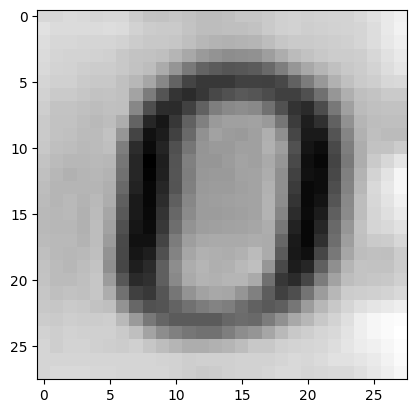

In [ ]:
from PIL import Image
from PIL import ImageOps
import torch
import numpy as np
import matplotlib.pyplot as plt

# Load the image
img = Image.open("3.png")

# Resize the image
img = img.resize((28, 28))

# Convert the image to grayscale
img = img.convert("L")

# Invert the image
img = ImageOps.invert(img)

plt.imshow(img, cmap='gray')
plt.show()

# Convert the image to a PyTorch tensor
img_tensor = torch.tensor(np.array(img)).float()

# Normalize the image
img_tensor /= 255.0

# Reshape the image to match the PyTorch MNIST dataset format
img_tensor = img_tensor.view(1, 28, 28)
#img_tensor.unsqueeze(0)


In [ ]:
o = cnn(img_tensor.unsqueeze(0))[0]
torch.max(o, 1)[1].data.squeeze()
o.argmax().item()


8

In [ ]:
import cv2
def red_check(img):
    # Define the lower and upper boundaries of the red color in HSV color space
    lower_red = np.array([0, 50, 550])
    upper_red = np.array([10, 200, 200])
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    red_mask1 = cv2.inRange(hsv, lower_red, upper_red)

    lower_red = np.array([170,50,50])
    upper_red = np.array([180,255,255])
    mask2 = cv2.inRange(hsv, lower_red, upper_red)

    red_mask = red_mask1 + mask2
    # Check if there are any white pixels in the red mask
    if cv2.countNonZero(red_mask) > 0:
        print("There is red color in the image")
    else:
        print("There is no red color in the image")

There is no red color in the image


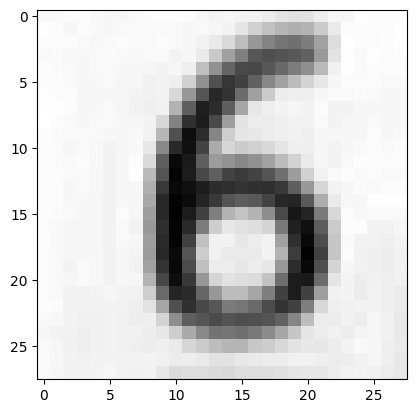

In [ ]:
import cv2
crop_img = cv2.imread("2.png")
red_check(crop_img)
crop_img = cv2.resize(crop_img, (28, 28))
crop_img = cv2.cvtColor(crop_img, cv2.COLOR_BGR2GRAY)
crop_img = cv2.bitwise_not(crop_img)
plt.imshow(crop_img, cmap='gray')
plt.show()

In [ ]:
from PIL import Image

# Open the image file
image = Image.open("3.png")

# Set the new width and height
new_size = (28, 28)

# Resize the image
resized_image = image.resize(new_size, resample=Image.BICUBIC)

plt.imshow(resized_image, cmap='gray')

NameError: name 'plt' is not defined

6



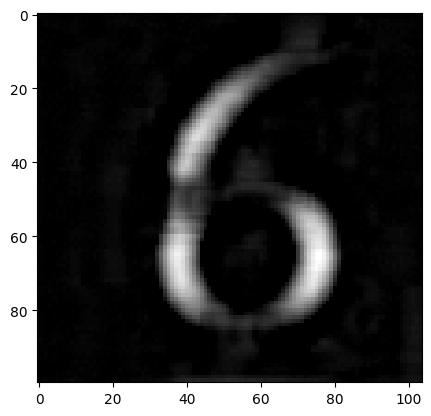

In [18]:
import pytesseract
import cv2
import matplotlib.pyplot as plt
image = cv2.imread("2.png")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
rectKernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
t = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, rectKernel)

output = pytesseract.image_to_string(t, lang='eng', config='--psm 10 --oem 3 -c tessedit_char_whitelist=0123456789')
print(output)
plt.imshow(t, cmap='gray')
plt.show()